In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)

BASE_DIR = '/content/drive/MyDrive/deepfake_detection'
STATS_DIR  = os.path.join(BASE_DIR, 'stats')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"Seed set to {SEED}")

Seed set to 42


In [5]:
with open(os.path.join(STATS_DIR, 'manifest.json')) as f:
    manifest = json.load(f)

# loading the identical split used by the LSTM model
with open(os.path.join(STATS_DIR, 'train_val_test_split.json')) as f:
    split_info = json.load(f)

train_sources = set(split_info['train_source_ids'])
val_sources = set(split_info['val_source_ids'])
test_sources = set(split_info['test_source_ids'])

train_manifest = [m for m in manifest if m['source_id'] in train_sources]
val_manifest = [m for m in manifest if m['source_id'] in val_sources]
test_manifest = [m for m in manifest if m['source_id'] in test_sources]

def split_summary(name, entries):
    real = sum(1 for m in entries if m['label'] == 0)
    fake = sum(1 for m in entries if m['label'] == 1)
    print(f"{name:6s}: {len(entries):4d} videos  (real={real}, fake={fake})")

split_summary("Train", train_manifest)
split_summary("Val",   val_manifest)
split_summary("Test",  test_manifest)

Train : 1600 videos  (real=800, fake=800)
Val   :  200 videos  (real=100, fake=100)
Test  :  200 videos  (real=100, fake=100)


In [6]:
class FrameDataset(Dataset):
  def __init__(self, manifest_entries):
    self.frames = []
    for entry in tqdm(manifest_entries, desc='Loading frames'):
      features = np.load(entry['path']).astype(np.float32)
      label = entry['label']
      for feat in features:
          self.frames.append((feat, label))

  def __len__(self):
    return len(self.frames)

  def __getitem__(self, idx):
    feat, label = self.frames[idx]
    return torch.tensor(feat), torch.tensor(label, dtype=torch.float32)

print("Building train dataset...")
train_dataset = FrameDataset(train_manifest)
print(f"  {len(train_dataset):,} frames from {len(train_manifest)} videos")

print("Building val dataset...")
val_dataset = FrameDataset(val_manifest)
print(f"  {len(val_dataset):,} frames from {len(val_manifest)} videos")

print("Building test dataset (held out until final evaluation)...")
test_dataset = FrameDataset(test_manifest)
print(f"  {len(test_dataset):,} frames from {len(test_manifest)} videos")

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1024, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1024, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain loader : {len(train_loader)} batches")
print(f"Val   loader : {len(val_loader)} batches")
print(f"Test  loader : {len(test_loader)} batches  (not used during training)")

Building train dataset...


Loading frames: 100%|██████████| 1600/1600 [12:09<00:00,  2.19it/s]


  296,836 frames from 1600 videos
Building val dataset...


Loading frames: 100%|██████████| 200/200 [01:31<00:00,  2.18it/s]


  38,625 frames from 200 videos
Building test dataset (held out until final evaluation)...


Loading frames: 100%|██████████| 200/200 [01:31<00:00,  2.19it/s]

  38,403 frames from 200 videos

Train loader : 290 batches
Val   loader : 38 batches
Test  loader : 38 batches  (not used during training)


In [7]:
class SimpleFrameMLP(nn.Module):
  def __init__(self, input_dim=2048):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
    )

  def forward(self, x):
      return self.net(x).squeeze(1)

model = SimpleFrameMLP().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {model}")
print(f"\nTrainable parameters: {total_params:,}")

Model: SimpleFrameMLP(
  (net): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=1, bias=True)
  )
)

Trainable parameters: 524,801


In [8]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for feats, labels in loader:
            feats, labels = feats.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(feats)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            preds   = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total   += len(labels)
    return total_loss / total, correct / total

print("Training helpers defined.")

Training helpers defined.


In [9]:
MAX_EPOCHS = 20
ES_PATIENCE = 5
LR_PATIENCE = 3
LR_FACTOR = 0.5
SMOOTH_WIN = 3

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

log_rows = []
val_loss_history = []
best_val_loss = float('inf')
best_val_acc = 0.0
best_epoch = 0
epochs_no_improve = 0

print(f"Training baseline MLP up to {MAX_EPOCHS} epochs, early stopping patience={ES_PATIENCE}")
print()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    val_loss, val_acc = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)

    current_lr = optimizer.param_groups[0]['lr']
    val_loss_history.append(val_loss)
    smoothed = float(np.mean(val_loss_history[-SMOOTH_WIN:]))
    scheduler.step(smoothed)

    row = dict(epoch=epoch,
               train_loss=round(train_loss, 5), val_loss=round(val_loss, 5),
               smoothed_val_loss=round(smoothed, 5),
               train_acc=round(train_acc, 5),   val_acc=round(val_acc, 5),
               lr=current_lr)
    log_rows.append(row)

    print(f"Epoch {epoch:03d} | "
          f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} (smooth={smoothed:.4f})  val_acc={val_acc:.4f} | "
          f"lr={current_lr:.2e}")

    # Save best checkpoint (by val accuracy similar to our LSTM)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'baseline_mlp_best.pt'))
        print(f" New best val_acc={best_val_acc:.4f}  →  saved baseline_mlp_best.pt")

    # Early stopping (by smoothed val loss)
    if smoothed < best_val_loss:
        best_val_loss = smoothed
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= ES_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no val loss improvement for {ES_PATIENCE} epochs).")
        break

torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'baseline_mlp_final.pt'))
print(f"\nFinal checkpoint  → baseline_mlp_final.pt")
print(f"Best  checkpoint  → baseline_mlp_best.pt  (epoch {best_epoch}, val_loss={best_val_loss:.4f})")

Training baseline MLP up to 20 epochs, early stopping patience=5

Epoch 001 | train_loss=0.5234  train_acc=0.7330 | val_loss=0.4608 (smooth=0.4608)  val_acc=0.7700 | lr=1.00e-03
 New best val_acc=0.7700  →  saved baseline_mlp_best.pt
Epoch 002 | train_loss=0.3957  train_acc=0.8169 | val_loss=0.4506 (smooth=0.4557)  val_acc=0.7802 | lr=1.00e-03
 New best val_acc=0.7802  →  saved baseline_mlp_best.pt
Epoch 003 | train_loss=0.3186  train_acc=0.8626 | val_loss=0.4365 (smooth=0.4493)  val_acc=0.7896 | lr=1.00e-03
 New best val_acc=0.7896  →  saved baseline_mlp_best.pt
Epoch 004 | train_loss=0.2637  train_acc=0.8916 | val_loss=0.4447 (smooth=0.4440)  val_acc=0.7962 | lr=1.00e-03
 New best val_acc=0.7962  →  saved baseline_mlp_best.pt
Epoch 005 | train_loss=0.2228  train_acc=0.9108 | val_loss=0.4664 (smooth=0.4492)  val_acc=0.7986 | lr=1.00e-03
 New best val_acc=0.7986  →  saved baseline_mlp_best.pt
Epoch 006 | train_loss=0.1954  train_acc=0.9225 | val_loss=0.4773 (smooth=0.4628)  val_acc=0.7

Training log saved: /content/drive/MyDrive/deepfake_detection/models/baseline_training_log.csv


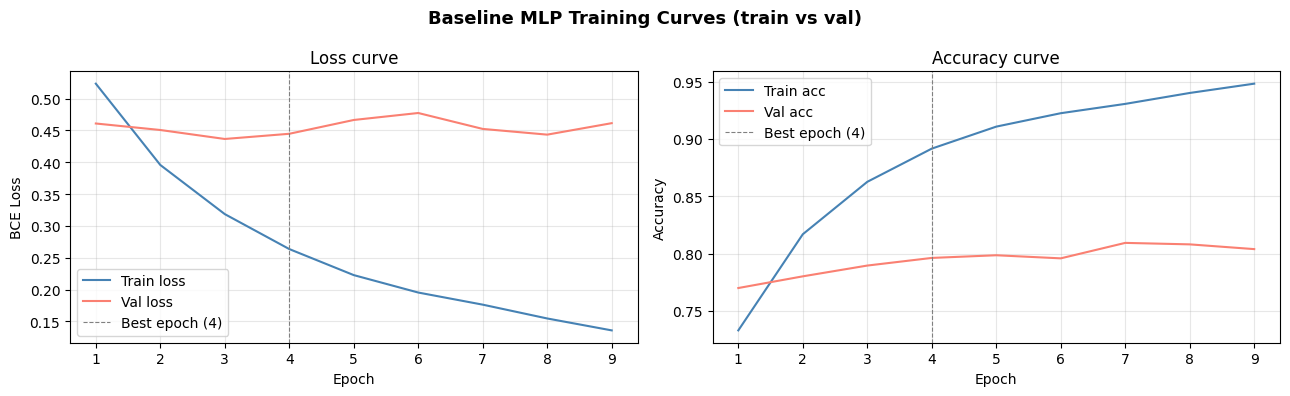

Saved: /content/drive/MyDrive/deepfake_detection/plots/baseline_training_curves.png

BASELINE MLP TRAINING SUMMARY
  Total epochs run : 9
  Best epoch : 4
  Best val loss : 0.44395
  Best val accuracy : 0.8094  (80.94%)
  Final train accuracy: 0.9483  (94.83%)


In [10]:
import csv

log_path = os.path.join(MODELS_DIR, 'baseline_training_log.csv')
with open(log_path, 'w', newline='') as fp:
    writer = csv.DictWriter(fp, fieldnames=log_rows[0].keys())
    writer.writeheader()
    writer.writerows(log_rows)
print(f"Training log saved: {log_path}")

epochs_ran = [r['epoch']      for r in log_rows]
t_loss = [r['train_loss'] for r in log_rows]
v_loss = [r['val_loss']   for r in log_rows]
t_acc = [r['train_acc']  for r in log_rows]
v_acc = [r['val_acc']    for r in log_rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, t_loss, label='Train loss', color='steelblue')
axes[0].plot(epochs_ran, v_loss, label='Val loss',   color='salmon')
axes[0].axvline(best_epoch, linestyle='--', color='gray', linewidth=0.8,
                label=f'Best epoch ({best_epoch})')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, t_acc, label='Train acc', color='steelblue')
axes[1].plot(epochs_ran, v_acc, label='Val acc',   color='salmon')
axes[1].axvline(best_epoch, linestyle='--', color='gray', linewidth=0.8,
                label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy curve')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline MLP Training Curves (train vs val)', fontsize=13, fontweight='bold')
plt.tight_layout()
curve_path = os.path.join(PLOTS_DIR, 'baseline_training_curves.png')
plt.savefig(curve_path, bbox_inches='tight')
plt.show()
print(f"Saved: {curve_path}")

print()
print("BASELINE MLP TRAINING SUMMARY")
print(f"  Total epochs run : {len(log_rows)}")
print(f"  Best epoch : {best_epoch}")
print(f"  Best val loss : {best_val_loss:.5f}")
print(f"  Best val accuracy : {max(v_acc):.4f}  ({max(v_acc)*100:.2f}%)")
print(f"  Final train accuracy: {t_acc[-1]:.4f}  ({t_acc[-1]*100:.2f}%)")

In [11]:
# Load best checkpoint
model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'baseline_mlp_best.pt'), map_location=DEVICE)
)
model.eval()
print(f"Loaded baseline_mlp_best.pt")
print("Running inference on held-out test set...")

y_true  = []
y_probs = []

with torch.no_grad():
  for entry in tqdm(test_manifest, desc='Evaluating'):
      features = torch.tensor(
          np.load(entry['path']).astype(np.float32)
      ).to(DEVICE)
      probs = torch.sigmoid(model(features)).cpu().numpy()
      y_probs.append(float(np.mean(probs)))   # mean-pool frame scores → video score
      y_true.append(entry['label'])

y_true  = np.array(y_true)
y_probs = np.array(y_probs)
y_pred  = (y_probs >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

print()
print("  BASELINE MLP — EVALUATION SUMMARY")
print()
print(f"  Aggregation : Mean pool (video level)")
print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}   ({accuracy_score(y_true, y_pred)*100:.2f}%)")
print(f"  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  Recall : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  F1 score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  AUC-ROC : {roc_auc_score(y_true, y_probs):.4f}")
print(f"  AUC-PR : {average_precision_score(y_true, y_probs):.4f}")
print(f"  FPR : {fpr_rate:.4f}  (real videos flagged as fake)")
print(f"  FNR : {fnr_rate:.4f}  (fake videos missed)")
print(f"  TP/TN/FP/FN : {tp} / {tn} / {fp} / {fn}")
print()
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

Loaded baseline_mlp_best.pt
Running inference on held-out test set...


Evaluating: 100%|██████████| 200/200 [00:01<00:00, 195.58it/s]


  BASELINE MLP — EVALUATION SUMMARY

  Aggregation : Mean pool (video level)
  Accuracy : 0.8800   (88.00%)
  Precision : 0.8958
  Recall : 0.8600
  F1 score : 0.8776
  AUC-ROC : 0.9315
  AUC-PR : 0.9435
  FPR : 0.1000  (real videos flagged as fake)
  FNR : 0.1400  (fake videos missed)
  TP/TN/FP/FN : 86 / 90 / 10 / 14

              precision    recall  f1-score   support

        Real       0.87      0.90      0.88       100
        Fake       0.90      0.86      0.88       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



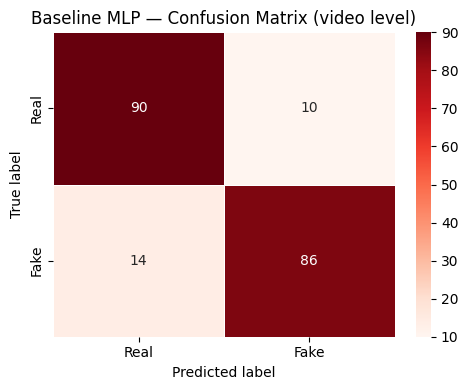

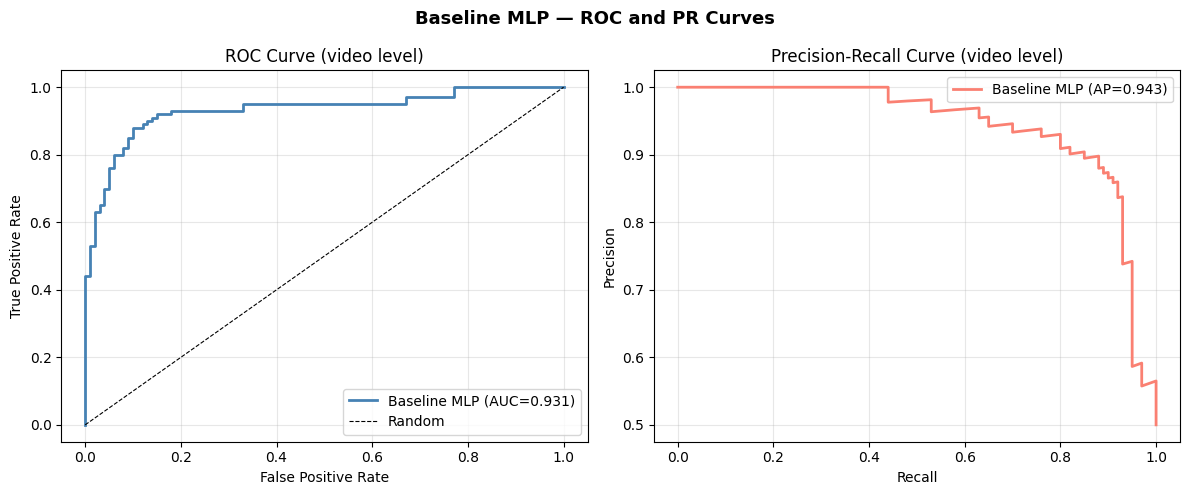

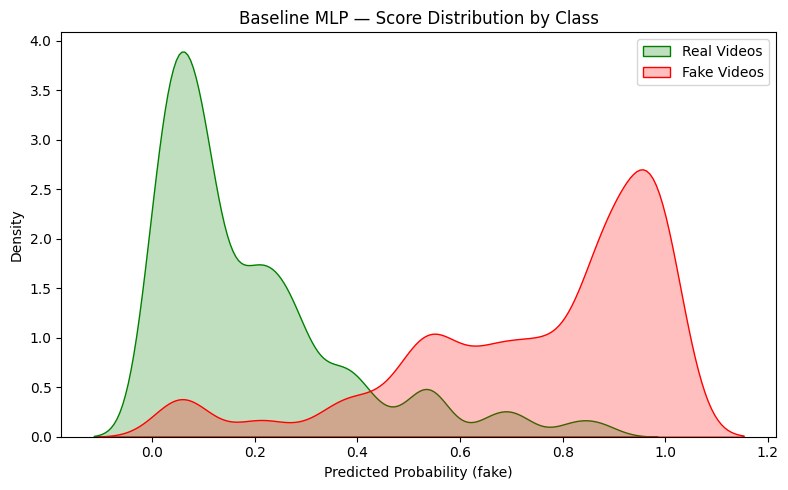

All plots saved.


In [12]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_true, y_pred, labels=[0, 1]),
    annot=True, fmt='d', cmap='Reds',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Baseline MLP — Confusion Matrix (video level)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'baseline_confusion_matrix.png'), bbox_inches='tight')
plt.show()

# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_arr, tpr_arr, _ = roc_curve(y_true, y_probs)
auc_roc = roc_auc_score(y_true, y_probs)
axes[0].plot(fpr_arr, tpr_arr, color='steelblue', lw=2, label=f'Baseline MLP (AUC={auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (video level)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_probs)
auc_pr = average_precision_score(y_true, y_probs)
axes[1].plot(recall_arr, precision_arr, color='salmon', lw=2, label=f'Baseline MLP (AP={auc_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (video level)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline MLP — ROC and PR Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'baseline_roc_pr_curves.png'), bbox_inches='tight')
plt.show()

# Score distribution — real vs fake separation
fig, ax = plt.subplots(figsize=(8, 5))
import seaborn as sns
real_probs = y_probs[y_true == 0]
fake_probs = y_probs[y_true == 1]
sns.kdeplot(real_probs, bw_adjust=0.5, fill=True, label='Real Videos', color='green', ax=ax)
sns.kdeplot(fake_probs, bw_adjust=0.5, fill=True, label='Fake Videos', color='red',   ax=ax)
ax.set_title('Baseline MLP — Score Distribution by Class')
ax.set_xlabel('Predicted Probability (fake)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'baseline_score_distribution.png'), bbox_inches='tight')
plt.show()

print("All plots saved.")